# 03/12

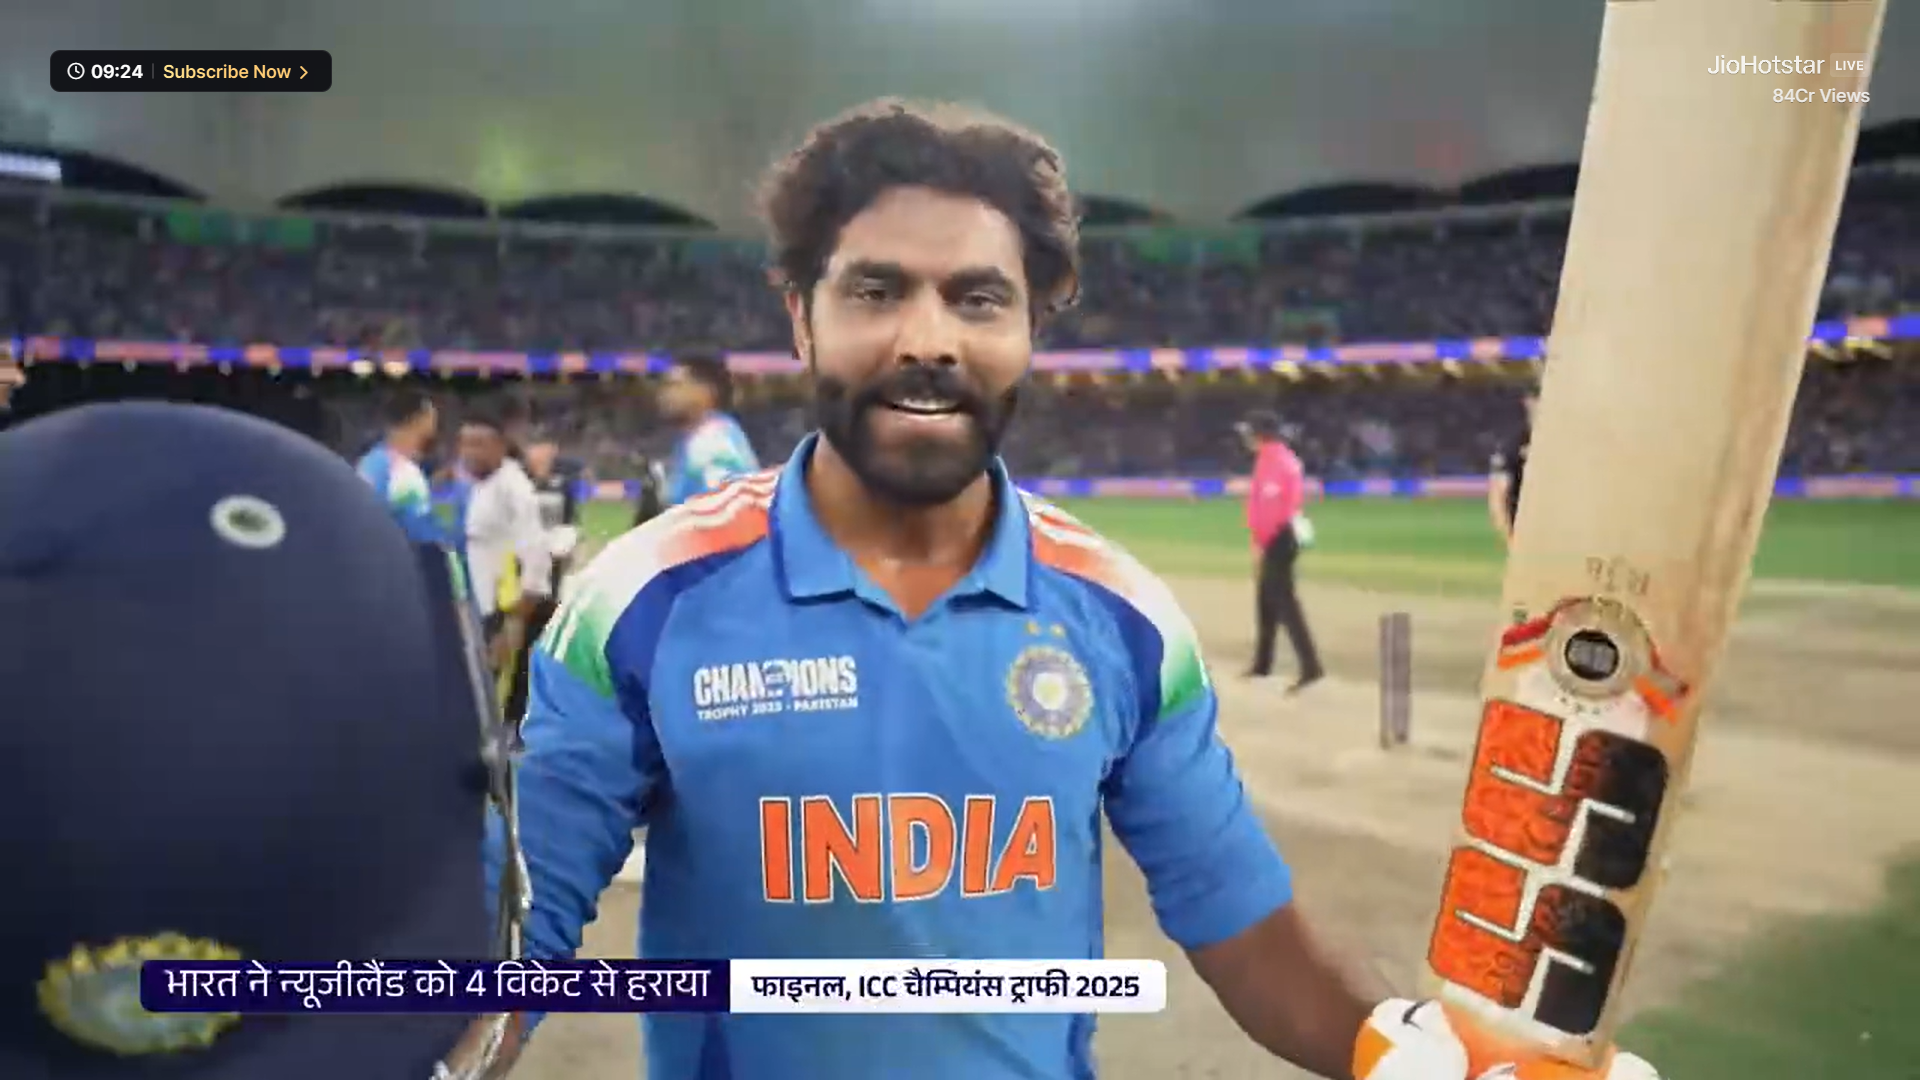

In [6]:
from PIL import Image
from IPython.display import Image as DisplayImage

img = Image.open("worldcup.png")

display(DisplayImage(filename="worldcup.png",height=400,width=600))

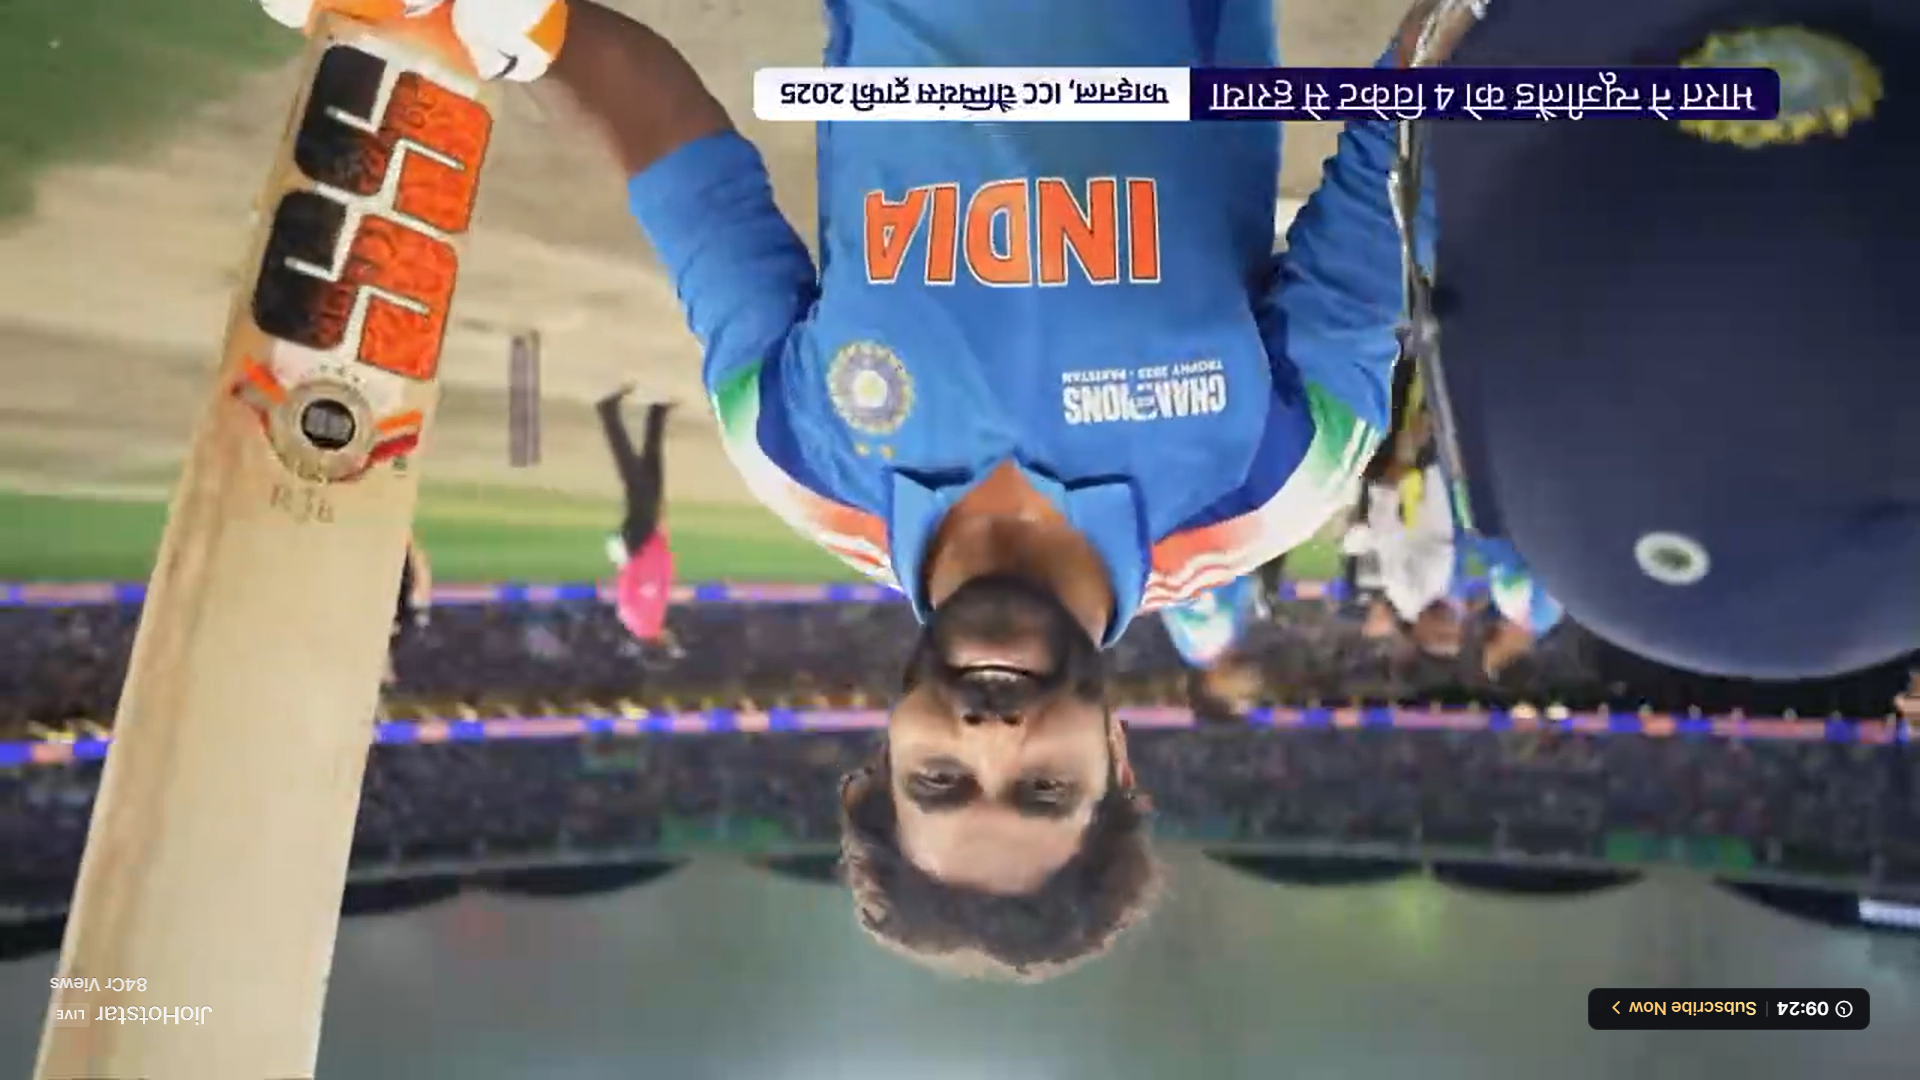

In [7]:
# img.rotate(45)
# img.rotate(90)
img.rotate(180)

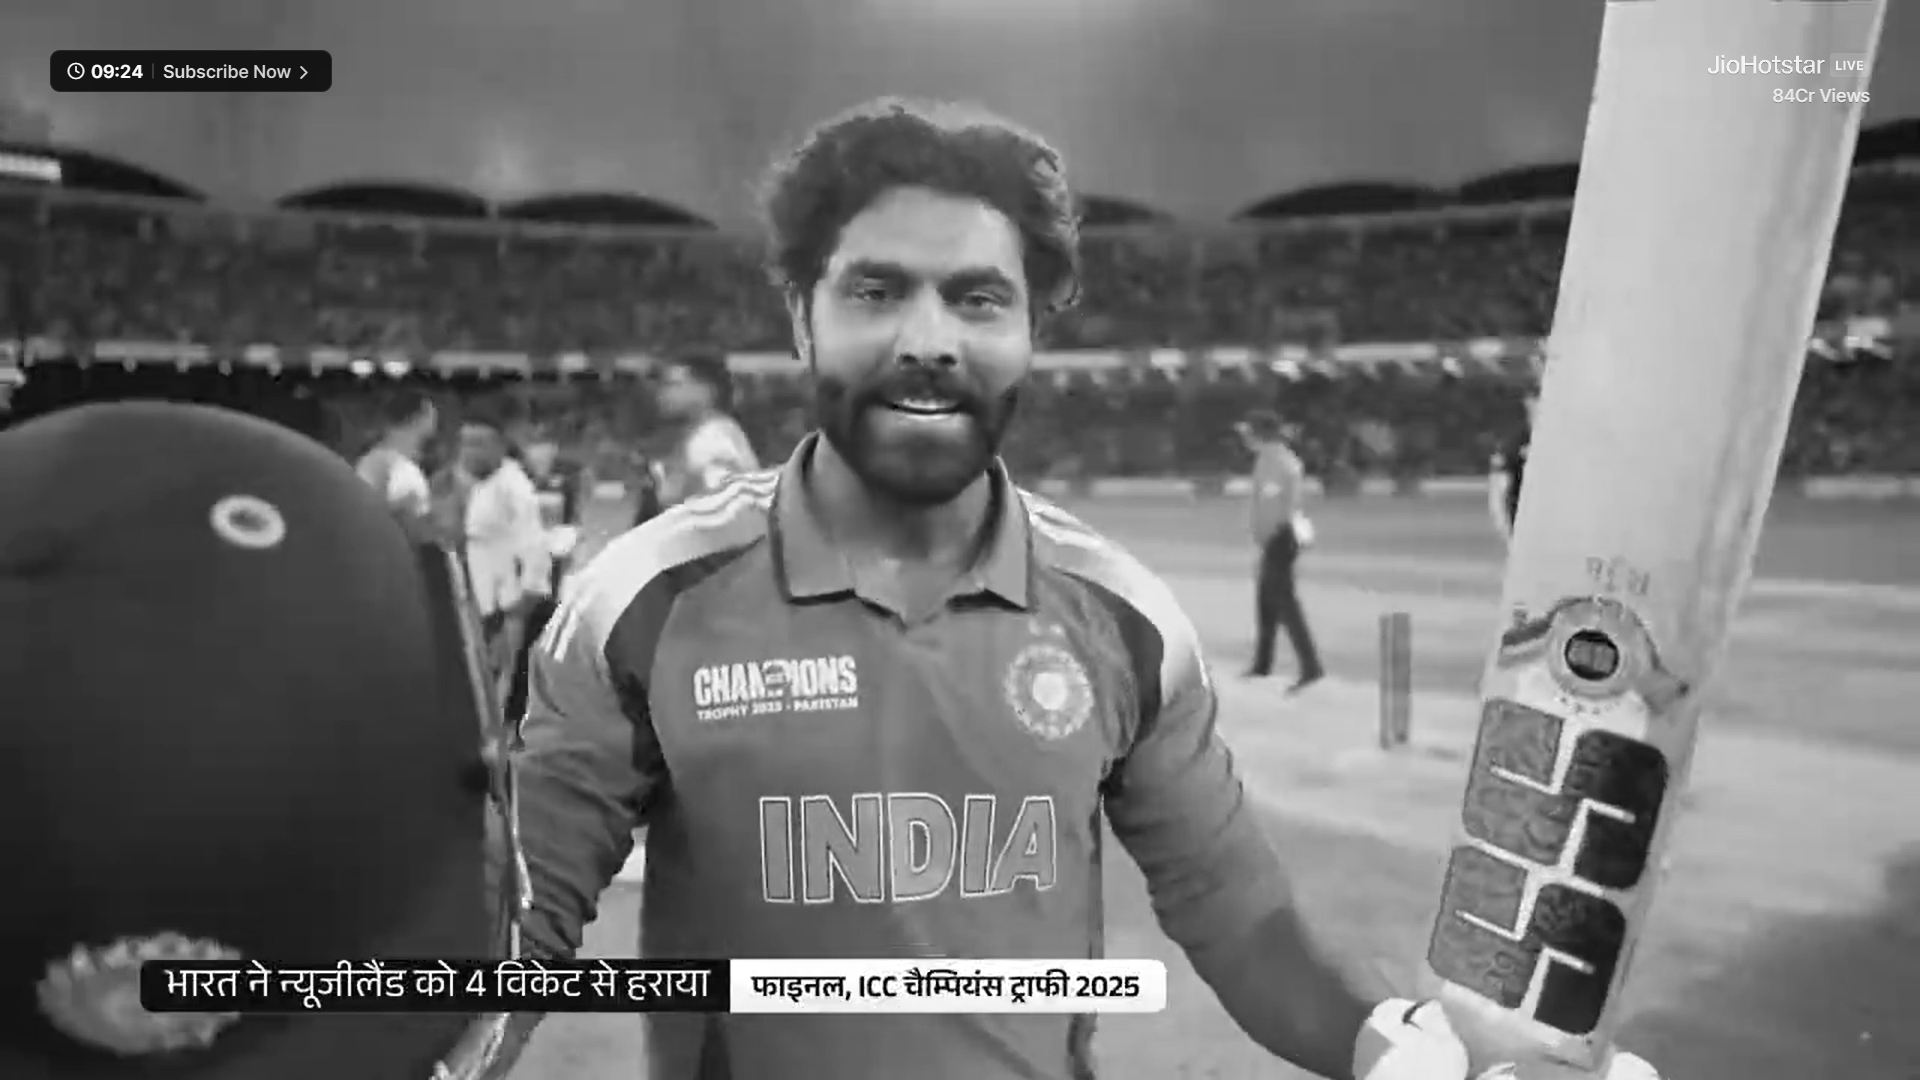

In [8]:
grey_img = img.convert("L")
grey_img

# Homework:

In [9]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.6 MB/s eta 0:00:00


In [10]:
from ultralytics import YOLO

# Load pretrained YOLOv8n model
model = YOLO('yolov8n.pt')
print(model.names)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47

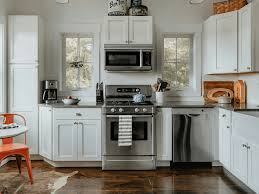

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


0: 480x640 1 chair, 2 microwaves, 1 oven, 76.3ms
Speed: 25.1ms preprocess, 76.3ms inference, 42.4ms postprocess per image at shape (1, 3, 480, 640)


list

In [11]:
from PIL import Image
from IPython.display import Image as DisplayImage

display(DisplayImage(filename="kitchen.jpg",height=400,width=600))

# Perform object detection on the image
img = Image.open("kitchen.jpg")
results = model.predict(source=img, show=True)
type(results)


# 06/12

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 89.2MB/s]


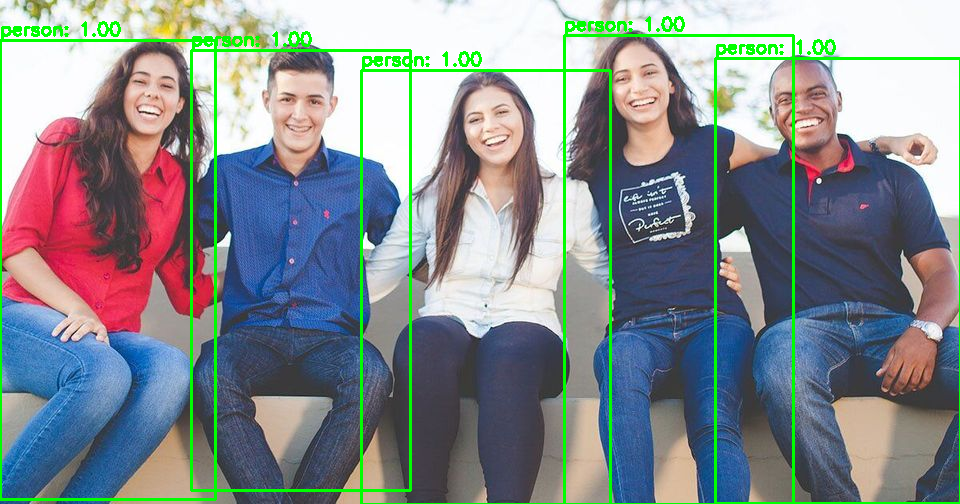

In [12]:
import torch
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
import cv2
from google.colab.patches import cv2_imshow

# Load the pre-trained Faster R-CNN model with default weights
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
model.eval() # Set the model to evaluation mode

# Get the COCO labels used by the model
labels = weights.meta["categories"]

# Path to the image file
img_path = "/content/person.jpg"
image = cv2.imread(img_path) # Read the image using OpenCV
orig = image.copy() # Create a copy of the original image to draw on

# Convert the image from BGR (OpenCV default) to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# Convert the image to a PyTorch tensor and add a batch dimension
tensor = F.to_tensor(image_rgb)
tensor = tensor.unsqueeze(0)

# Perform object detection
with torch.no_grad(): # Disable gradient calculation for inference
    predictions = model(tensor)

# Extract bounding boxes, confidence scores, and class labels from the predictions
boxes = predictions[0]["boxes"]
scores = predictions[0]["scores"]
classes = predictions[0]["labels"]

# Iterate through each detected object
for box, score, cls in zip(boxes, scores, classes):
    if score < 0.5: # Only consider detections with a confidence score above 0.5
        continue

    # Get the coordinates of the bounding box
    x1, y1, x2, y2 = box.int().tolist()
    # Format the label with the class name and confidence score
    label = f"{labels[cls.item()]}: {score:.2f}"

    # Draw the bounding box on the image
    cv2.rectangle(orig, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green rectangle with thickness 2
    # Put the label text above the bounding box
    cv2.putText(orig, label, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2) # Green text with scale 0.6 and thickness 2

# Display the image with detections
cv2_imshow(orig)
cv2.waitKey(0) # Wait indefinitely for a key press
cv2.destroyAllWindows() # Close all OpenCV windows

# 09/12

In [1]:
# import these modules
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

print("rocks :", lemmatizer.lemmatize("rocks"))
print("corpora :", lemmatizer.lemmatize("corpora"))

# a denotes adjective in "pos"
print("better :", lemmatizer.lemmatize("better",pos="a"))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\saina\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


rocks : rock
corpora : corpus
better : good


In [2]:
from nltk.stem import PorterStemmer

# Create a Porter Stemmer instance
porter_stemmer = PorterStemmer()

words = ["running", "jumps", "happily", "running", "happily"]

# Apply stemming to each word
stemmed_words = [porter_stemmer.stem(word) for word in words]

print("Original words:", words)
print("Stemmed words:", stemmed_words)

Original words: ['running', 'jumps', 'happily', 'running', 'happily']
Stemmed words: ['run', 'jump', 'happili', 'run', 'happili']


In [4]:
from nltk.stem import PorterStemmer

# Create a PorterStemmer instance
porter_stemmer = PorterStemmer()

# Read words from a text file
with open("C:\\Users\\saina\\Downloads\\New Text Document.txt", "r") as file:
    text = file.read()

# Split words by space or newline
words = text.split()

# Apply stemming
stemmed_words = [porter_stemmer.stem(word) for word in words]

# Print results
print("Original words:", words)
print("Stemmed words:", stemmed_words)

Original words: ['running', 'done', 'jumper', 'working', 'stemming', 'joinee', 'happened', 'hum', 'happier', 'download', 'gone', 'giving']
Stemmed words: ['run', 'done', 'jumper', 'work', 'stem', 'joine', 'happen', 'hum', 'happier', 'download', 'gone', 'give']


In [3]:
## Isolated forest
transactions = [
    (20, "local"),  # grocery
    (50, "local"),  # gas
    (500, "local"), # online shopping
    (500, "foreign"), # jewelry purchase abroad
    (800, "local"), # electronics
]

# thresholds
MAX_NORMAL_AMOUNT = 500
ALLOWED_LOCATIONS = ["local"]

def detect_anomalies(transactions):
    anomalies = []

    for idx, (amount, location) in enumerate(transactions, start=1):
        if amount > MAX_NORMAL_AMOUNT or location not in ALLOWED_LOCATIONS:
            anomalies.append({
                "transaction_id": idx,
                "amount": amount,
                "location": location,
                "reason": "High amount" if amount > MAX_NORMAL_AMOUNT else "Unusual location"
            })

    return anomalies

anomalies = detect_anomalies(transactions)
print(f"{anomalies}\n\n")

if anomalies:
    print("Suspicious transactions detected:")
    for anomaly in anomalies:
        print(f"ID {anomaly['transaction_id']}: ${anomaly['amount']} at {anomaly['location']} -> {anomaly['reason']}")
else:
    print("No anomalies detected.")

[{'transaction_id': 4, 'amount': 500, 'location': 'foreign', 'reason': 'Unusual location'}, {'transaction_id': 5, 'amount': 800, 'location': 'local', 'reason': 'High amount'}]


Suspicious transactions detected:
ID 4: $500 at foreign -> Unusual location
ID 5: $800 at local -> High amount


# 10/12

In [15]:
print("Chatbot: Hi! Chatbot here. Type 'bye' to exit.")

while True:
    user = input("You: ")

    if user.lower() in ["hi","hello"]:
        print("Chatbot: Hello! How can I help you?")
    elif user.lower() == "how are you":
        print("Chatbot: I am fine! Thank you")
    elif user.lower() == "tell me about yourself":
        print("Chatbot: I'm a chatbot at your service.")
    elif user.lower() in ["bye","good night"]:
        print("Chatbot: Goodbye! Have a nice day!")
        break
    else:
        print("Chatbot: Sorry, I don't understand.")

Chatbot: Hi! Chatbot here. Type 'bye' to exit.
You: hi
Chatbot: Hello! How can I help you?
You: how are you
Chatbot: I am fine! Thank you
You: abc
Chatbot: Sorry, I don't understand.
You: bye
Chatbot: Goodbye! Have a nice day!


In [16]:
class ChatBot:
    def __init__(self):
        # Group questions that should have the same answer
        self.responses = {
            "My name is ChatBot!": [
                "what is your name",
                "what's your name",
                "who are you",
                "tell me your name",
                "your name",
                "what should i call you"
            ],
            "I'm doing great, thanks!": [
                "how are you",
                "how are you doing",
                "how do you feel",
                "are you ok",
                "how's it going",
                "what's up"
            ],
            "I'm a chatbot created to help you!": [
                "what are you",
                "what do you do",
                "what is your purpose",
                "why do you exist",
                "what's your function"
            ],
            "I was built using Python.": [
                "what programming language are you built in",
                "what code were you written in",
                "what is your source code",
                "which language do you use",
                "what language are you programmed in",
                "your programming language",
                "what language do you speak"
            ],
            "You're Welcome!": [
                "thank you",
                "thanks",
                "thank you",
                "thank you very much",
                "thanks a lot",
                "cheers"
            ],
            "Goodbye! Have a nice day!": [
                "bye",
                "goodbye",
                "see you later",
                "have a nice day",
                "good night",
                "talk to you later"
            ],
            "I operate on a server, so I don't have a physical location.": [
                "where are you from",
                "where do you live",
                "what's your location"
            ],
            "I don't have personal feelings, but I'm here to assist you!": [
                "do you have feelings",
                "are you happy",
                "are you sad"
            ],
            "I can provide information, answer questions, and help with tasks.": [
                "what can you do",
                "how can you help me",
                "what are your capabilities"
            ],
            "I was created by a developer as a project.": [
                "who created you",
                "who is your boss",
                "who designed you"
            ],
            "I am always learning and improving!": [
                "are you smart",
                "how intelligent are you",
                "can you learn"
            ],
            "My goal is to be helpful and efficient.": [
                "what is your goal",
                "what's your objective"
            ],
            "I can communicate in many languages, but I primarily use English.": [
                "what languages do you speak",
                "do you know other languages"
            ],
            "I don't have a favorite color, but I find all colors fascinating.": [
                "what's your favorite color",
                "do you like colors",
                "favorite color"
            ],
            "I am a program, so I don't eat or drink.": [
                "what do you eat",
                "do you drink",
                "your favourite food",
                "your favourite drink"
            ]
        }

    def get_response(self, user_input):
        user_input = user_input.lower().strip()

        # Check each answer's associated questions
        for answer, questions in self.responses.items():
            for question in questions:
                if question in user_input:
                    return answer

        return "Sorry, I don't understand."

chatbot = ChatBot()
print(chatbot.get_response("your name"))
print(chatbot.get_response("why do you exist"))
print(chatbot.get_response("how's it going"))
print(chatbot.get_response("your programming language"))
print(chatbot.get_response("  xnasjc "))
print(chatbot.get_response("thanks"))
print(chatbot.get_response("see you later"))
print(chatbot.get_response("where are you from"))
print(chatbot.get_response("do you have feelings"))
print(chatbot.get_response("what can you do"))
print(chatbot.get_response("who created you"))
print(chatbot.get_response("are you smart"))
print(chatbot.get_response("what is your goal"))
print(chatbot.get_response("what languages do you speak"))
print(chatbot.get_response("what's your favorite color"))
print(chatbot.get_response("what do you eat"))
print(chatbot.get_response("what's your gender"))

My name is ChatBot!
I'm a chatbot created to help you!
I'm doing great, thanks!
I was built using Python.
Sorry, I don't understand.
You're Welcome!
Goodbye! Have a nice day!
I operate on a server, so I don't have a physical location.
I don't have personal feelings, but I'm here to assist you!
I can provide information, answer questions, and help with tasks.
I was created by a developer as a project.
I am always learning and improving!
My goal is to be helpful and efficient.
I can communicate in many languages, but I primarily use English.
I don't have a favorite color, but I find all colors fascinating.
I am a program, so I don't eat or drink.
Sorry, I don't understand.


# 11/12

In [17]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 5.7 MB/s eta 0:00:00


In [19]:
from groq import Groq
from google.colab import userdata

client = Groq(api_key=userdata.get('groqAPI'))

def ask_bot(prompt):
    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[
            {"role": "user", "content": prompt}
        ]
    )

    return response.choices[0].message.content

print("AI Chatbot Ready! Type 'quit' to exit.\n")

while True:
    user = input("You: ")

    if user.lower() in ["quit","bye","good bye","good night"]:
        print("Bot: Bye!")
        break

    print("Bot:", ask_bot(user))

AI Chatbot Ready! Type 'quit' to exit.

You: hello
Bot: Hello! How can I help you today?
You: tell me about history of engineering
Bot: ## A Brief Journey Through the History of Engineering  

Engineering is the art and science of turning ideas into practical solutions. Its story stretches from the first stone tools of pre‑history to today’s AI‑driven design platforms. Below is a chronological overview that highlights key periods, landmark achievements, and influential figures.

---

### 1. Pre‑historic & Ancient Foundations (≈ 30 k–500 BC)

| Era / Region | What People Built | Engineering Highlights |
|--------------|-------------------|------------------------|
| **Stone Age** (c. 30 k – 10 k BC) | Simple tools, shelters, early water‑management (e.g., drainage ditches). | Mastery of **stone knapping** and basic **material selection**. |
| **Neolithic** (≈ 10 k BC) | Irrigation canals (e.g., in the Indus Valley), early **roads**, and **grain storage** structures. | First organized **c

# 12/12

In [22]:
from groq import Groq

client = Groq(api_key=userdata.get('groqAPI'))
filename = "/content/Aarambh.mpeg"

with open(filename, "rb") as file:
    transcription = client.audio.transcriptions.create(
      file=(filename, file.read()),
      model="whisper-large-v3",
      temperature=0,
      response_format="verbose_json",
    )

    print(transcription.text)

 । । । । । । । offi आज एक धनुष के बाण पे उतार लो आरंभ है प्रचंड मन करे सो प्राण दे जो मन करे सो प्राण ले वहीं तो एक सर्वशक्तिमान है मन करे सौ प्राण दे जो मन करे सौ प्राण ले वहीं तो एक सर्वशक्तिमान है किष्ठ की कुकार है ये भागवत का सार है कि युद ही तो वीर का प्रमान है पौरों की भीड हो या पांडवों का नीढ हो आरंब है प्रचंड, बोले मस्तकों के जुन्ड बाज, जंग की हड़ी की तूँग आर दो आन पान शान या कि जान का हो दान आज इतन उश्के बान पे उदार दो आरंभ है प्रचन वो दया का भाव या कि शौरे का चुनाव या कि हार का वो घाव तुम ये सोच लो या कि पूरे भाल पर जला रहे विचाय का लाल लाल ये गुलाल तुम ये सोच लो उस कवी को आज तुम नकार दो बीगती मसों में आज फूलती रगों में आज वाग की लपट का तुम बघार दो आरंप है प्रचंड बोल मस्तकों के जुन्द आज जंग की घड़ी की तुम्बू आर दो आनवान शान्या की जान का हो दान आज इधनुष के बान पे उतार दो आरंप है प्रचंड आरंब है प्रचन प्राप्त प्राप्त


In [23]:
!pip install openai-whisper langdetect pydub
!apt-get install ffmpeg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 19.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 54.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=2f82f2510e14d550f5fd5f2a250a90753097083d3dfe92877262bc671eb4e447
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=d4bd6f71d9cf131c066ca1b11d4a7e31d22d895bcac3fa38f5f8e2be330fcd56
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built openai-whisper langdetect
Reading package lists... Done
Building dependency tree... Done
Reading sta

In [24]:
import whisper
from langdetect import detect, LangDetectException
from pydub import AudioSegment

# # STEP 1: Convert MP3 to WAV
# # ---------------------------------------

audio_path = "/content/Aarambh.mpeg"
wav_path = "/content/Aarambh.mpeg"

AudioSegment.from_mp3(audio_path).export(wav_path, format="wav")
print("MP3 converted to WAV")

# # STEP 2: Load Whisper model
# # ---------------------------------------
print("Loading Whisper model... (takes 20-30 sec)")
model = whisper.load_model("small") # You can use "base" if GPU is slow

# # STEP 3: Transcribe audio
# # ---------------------------------------
print("Transcribing...")
result = model.transcribe(wav_path)
text = result["text"].strip()

print("\nTranscribed Text:\n", text)

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


MP3 converted to WAV
Loading Whisper model... (takes 20-30 sec)


100%|███████████████████████████████████████| 461M/461M [00:09<00:00, 51.8MiB/s]


Transcribing...

Transcribed Text:
 development With you too , I'll have to go . Who's this guy Come out Come out Come out The time of war is coming, you lose The life of the Manvanshan or the life of the Kahaudan Today, take it down on the mountain of Iqdan The beginning is a struggle, the words are the thorns of the masts The time of war is coming, you lose The life of the Manvanshan or the life of the Kahaudan Today, take it down on the mountain of Iqdan The beginning is a struggle The one who wants to live, the one who wants to take That is a powerful man The one who wants to live, the one who wants to take That is a powerful man The call of the Lord is the sound of the running The battle is the proof of the brave Whether it is the brave or the brave The one who fights is great There is no need to win, there is no need to lose The life of the Manvanshan or the life of the Kahaudan The time of war is coming, you lose The life of the Manvanshan or the life of the Kahaudan Today, take

# 15/12
Satellite Image Handling

Epoch [1/10], Loss: 1.1292
Epoch [2/10], Loss: 1.0945
Epoch [3/10], Loss: 0.8730
Epoch [4/10], Loss: 0.7452
Epoch [5/10], Loss: 2.7618
Epoch [6/10], Loss: 0.7079
Epoch [7/10], Loss: 0.7766
Epoch [8/10], Loss: 0.8876
Epoch [9/10], Loss: 0.9354
Epoch [10/10], Loss: 0.9489
Model saved as 'unet_satellite.pth'


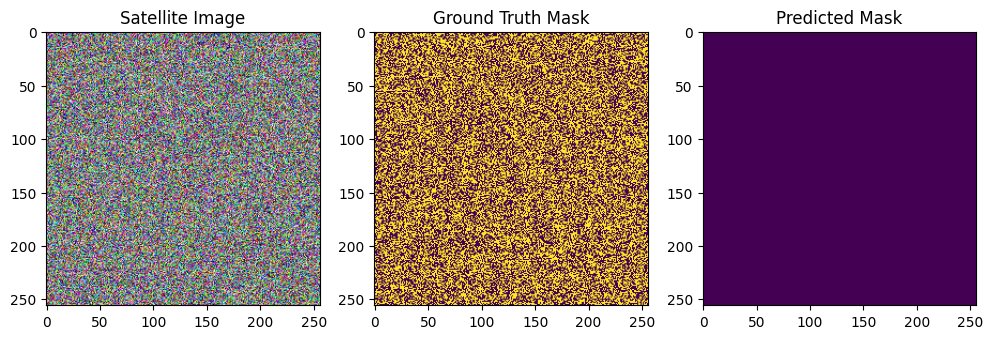

Predicted masks saved in 'predicted_masks'


In [25]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

#Dataset Class
class SatelliteDataset (Dataset):

    def __init__(self, image_dir, mask_dir, transform=None):

        self.image_dir = image_dir

        self.mask_dir = mask_dir

        self.transform = transform

        self.images = os.listdir(image_dir)

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        img_path= os.path.join(self.image_dir, self.images[idx])

        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = np.array(Image.open(img_path).convert("RGB"))

        mask = np.array(Image.open(mask_path).convert("L"))

        if self.transform:

            augmented = self.transform(image=image, mask=mask)

            image = augmented['image']

            mask = augmented['mask']

        image = transforms.ToTensor() (image)

        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask
#UNet Model

class DoubleConv(nn.Module):

    def __init__(self, in_ch, out_ch):

        super (DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_ch, out_ch, 3, padding=1),

            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),

            nn.ReLU(inplace=True)
        )
    def forward(self, x):

        return self.conv(x)

class UNet(nn.Module):

    def __init__(self, n_classes):

        super(UNet, self).__init__()

        self.dconv_down1 = DoubleConv(3, 64)

        self.dconv_down2 = DoubleConv(64, 128)

        self.dconv_down3 = DoubleConv(128, 256)

        self.maxpool = nn.MaxPool2d(2)

        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.dconv_up2 = DoubleConv(256+128, 128)
        self.dconv_up1 = DoubleConv (128+64, 64)

        self.conv_last = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):

        # Encoder

        conv1= self.dconv_down1(x)

        x= self.maxpool (conv1)

        conv2= self.dconv_down2(x)

        x= self.maxpool (conv2)

        x= self.dconv_down3(x)

        # Decoder

        # This part needs to be reviewed as the code is incomplete/malformed
        # It seems like there's a missing assignment or a variable name for the upsampled output
        # and then the torch.cat is also standalone without assignment.
        # Assuming the intent was something like:


        x = self.upsample(x) # Fixed assignment
        x = torch.cat([x, conv2], dim=1) # Fixed assignment

        x= self.dconv_up2(x)

        x= self.upsample(x)

        x = torch.cat([x, conv1], dim=1)

        x= self.dconv_up1(x)

        x = self.conv_last(x)

        return x

# Hyperparameters
batch_size=4

lr = 1e-3 # Corrected typo from '1r 1e-3'

num_epochs = 10

n_classes = 3

#Load Dataset

#Create dummy directories for images and masks to prevent FileNotFoundError

#In a real scenario, you would upload your dataset to these paths or mount Google Drive.

os.makedirs("images/train", exist_ok=True)

os.makedirs("masks/train", exist_ok=True)

#Create dummy image and mask files to avoid empty dataset error

dummy_image = Image.fromarray(np.random.randint(0, 255, (256, 256, 3), dtype=np.uint8))
dummy_mask = Image.fromarray(np.random.randint(0, n_classes - 1, (256, 256), dtype=np.uint8))

dummy_image.save("images/train/dummy_image.png")
dummy_mask.save("masks/train/dummy_image.png")

train_dataset = SatelliteDataset("images/train", "masks/train")

train_loader = DataLoader (train_dataset, batch_size=batch_size, shuffle=True)
#Device, Model, Loss, Optimizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Corrected 'cри'

model = UNet(n_classes=n_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=lr) # Corrected assignment

#Training Loop

#

for epoch in range(num_epochs):

    model.train()

    epoch_loss = 0.0 # Initialized epoch_loss

    for imgs, masks in train_loader:

        imgs = imgs.to(device) # Corrected assignment
        masks = masks.to(device) # Corrected assignment

        outputs = model(imgs)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(train_loader):.4f}") # Fixed f-string

#

#Save Model
torch.save(model.state_dict(), "unet_satellite.pth")

print("Model saved as 'unet_satellite.pth'") # Fixed quotes


#Visualize Predictions

# Removed 'ge.png' as it's not a valid Python statement

model.eval()

sample_img, sample_mask = train_dataset[0] # Corrected assignment

with torch.no_grad():

    pred = model(sample_img.unsqueeze(0).to(device))

    pred_mask = torch.argmax(pred.squeeze(), dim=0).cpu().numpy() # Corrected 'dim-0'

# Removed 'ge.png' as it's not a valid Python statement

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)

plt.imshow(sample_img.permute(1,2,0))

plt.title("Satellite Image")

plt.subplot(1,3,2)

plt.imshow(sample_mask)

plt.title("Ground Truth Mask")

plt.subplot(1,3,3)

plt.imshow(pred_mask)

plt.title("Predicted Mask")

plt.show()

#Save Predicted Masks
os.makedirs("predicted_masks", exist_ok=True)

for i in range(len(train_dataset)):

    img, _ = train_dataset[i] # Corrected assignment and ignored mask since not used

    with torch.no_grad():

        pred = model(img.unsqueeze(0).to(device)) # Corrected 'unsqueeze(8)' to 'unsqueeze(0)'

        pred_mask = torch.argmax(pred.squeeze(), dim=0).cpu().numpy() # Corrected 'dim=8' to 'dim=0'

    mask_img = Image.fromarray(pred_mask.astype(np.uint8)) # Corrected 'np.uints' to 'np.uint8'

    mask_img.save(f"predicted_masks/mask_{i}.png")

print("Predicted masks saved in 'predicted_masks'")

# 17/12
Collaborative_Filtering_for_Movie_Recommendation

In [26]:
import pandas as pd
import numpy as np
from zipfile import ZipFile
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
import matplotlib.pyplot as plt

In [27]:
movielens_data_file_url = (
    "http://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
)

movielens_zipped_file = keras.utils.get_file(
    "ml-latest-small.zip", movielens_data_file_url, extract=False
)

keras_datasets_path = Path(movielens_zipped_file).parents[0]
movielens_dir = keras_datasets_path / "ml-latest-small"

# Only extract the data the first time the script is run.
if not movielens_dir.exists():
    with ZipFile(movielens_zipped_file, "r") as zip:
        # Extract files
        print("Extracting all the files now...")
        zip.extractall(path=keras_datasets_path)
        print("Done!")

ratings_file = movielens_dir / "ratings.csv"
tags_file = movielens_dir / "tags.csv"
movies_file = movielens_dir / "movies.csv"

df = pd.read_csv(ratings_file)
tags = pd.read_csv(tags_file)
movies = pd.read_csv(movies_file)

978202/978202 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extracting all the files now...
Done!


In [28]:
df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [29]:
# Map user ID to a "user vector" via an embedding matrix
user_ids = df["userId"].unique().tolist()
user2user_encoded = {x: i for i, x in enumerate(user_ids)}
userencoded2user = {i: x for i, x in enumerate(user_ids)}

# Map movies ID to a "movies vector" via an embedding matrix
movie_ids = df["movieId"].unique().tolist()
movie2movie_encoded = {x: i for i, x in enumerate(movie_ids)}
movie_encoded2movie = {i: x for i, x in enumerate(movie_ids)}

df["user"] = df["userId"].map(user2user_encoded)
df["movie"] = df["movieId"].map(movie2movie_encoded)

num_users = len(user2user_encoded)
num_movies = len(movie_encoded2movie)
df['rating'] = df['rating'].values.astype(np.float32)

# min and max ratings will be used to normalize the ratings later
min_rating = min(df["rating"])
max_rating = max(df["rating"])

print(f"Number of users: {num_users}, Number of Movies: {num_movies}, Min Rating: {min_rating}, Max Rating: {max_rating}")

Number of users: 610, Number of Movies: 9724, Min Rating: 0.5, Max Rating: 5.0


In [30]:
df

,userId,movieId,rating,timestamp,user,movie
0,1,1,4.0,964982703,0,0
1,1,3,4.0,964981247,0,1
2,1,6,4.0,964982224,0,2
3,1,47,5.0,964983815,0,3
4,1,50,5.0,964982931,0,4
...,...,...,...,...,...,...
100831,610,166534,4.0,1493848402,609,3120
100832,610,168248,5.0,1493850091,609,2035
100833,610,168250,5.0,1494273047,609,3121
100834,610,168252,5.0,1493846352,609,1392


In [31]:
df = df.sample(frac=1, random_state=42)
x = df[["user", "movie"]].values

# Normalizing the targets between 0 and 1. Makes it easy to train.
y = df["rating"].apply(lambda x: (x - min_rating) / (max_rating - min_rating)).values

# Assuming training on 90% of the data and validating on 100%
train_indices = int(0.9 * df.shape[0])
x_train, x_val, y_train, y_val = (
    x[:train_indices],
    x[train_indices:],
    y[:train_indices],
    y[train_indices:],
)

In [32]:
from tensorflow.keras import layers

EMBEDDING_SIZE = 50

class RecommenderNet(keras.Model):
    def __init__(self, num_users, num_movies, embedding_size, **kwargs):
        super(RecommenderNet, self).__init__(**kwargs)
        self.num_users = num_users
        self.num_movies = num_movies
        self.embedding_size = embedding_size
        self.user_embedding = layers.Embedding(
            num_users,
            embedding_size,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )
        self.user_bias = layers.Embedding(num_users, 1)
        self.movie_embedding = layers.Embedding(
            num_movies,
            embedding_size,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )
        self.movie_bias = layers.Embedding(num_movies, 1)

    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])
        movie_vector = self.movie_embedding(inputs[:, 1])
        movie_bias = self.movie_bias(inputs[:, 1])
        dot_user_movie = tf.tensordot(user_vector, movie_vector, 2)
        # Add all the components (including bias)
        x = dot_user_movie + user_bias + movie_bias
        # The sigmoid activation forces the rating to be between 0 and 11
        return tf.nn.sigmoid(x)

model = RecommenderNet(num_users, num_movies, EMBEDDING_SIZE)
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=0.001) # Changed 'lr' to 'learning_rate'
)

In [33]:
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=64,
    epochs=5,
#     verbose=1,
    validation_data=(x_val, y_val)
)

Epoch 1/5
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.6573 - val_loss: 0.6203
Epoch 2/5
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.6146 - val_loss: 0.6179
Epoch 3/5
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.6091 - val_loss: 0.6129
Epoch 4/5
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6085 - val_loss: 0.6122
Epoch 5/5
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6072 - val_loss: 0.6114


In [34]:
movie_df = pd.read_csv(movielens_dir / 'movies.csv')

user_id = df.userId.sample(1).iloc[0]
movies_watched_by_user = df[df.userId == user_id]
movies_not_watched = movie_df[~movie_df['movieId'].isin(movies_watched_by_user.movieId.values)]['movieId']

movies_not_watched = list(set(movies_not_watched).intersection(set(movie2movie_encoded.keys())))

movies_not_watched = [[movie2movie_encoded.get(x)] for x in movies_not_watched]

user_encoder = user2user_encoded.get(user_id)

user_movie_array = np.hstack(
    ([[user_encoder]] * len(movies_not_watched), movies_not_watched)
)

ratings = model.predict(user_movie_array).flatten()
top_ratings_indices = ratings.argsort()[-10:][::-1]
recommended_movie_ids = [
    movie_encoded2movie.get(movies_not_watched[x][0]) for x in top_ratings_indices
]
print("Showing recommendations for user: {}".format(user_id))
print("====" * 9)
print("Movies with high ratings from user")
print("----" * 8)
top_movies_user = (
    movies_watched_by_user.sort_values(by="rating", ascending=False)
    .head(5)
    .movieId.values
)
movie_df_rows = movie_df[movie_df["movieId"].isin(top_movies_user)]
for row in movie_df_rows.itertuples():
    print(row.title, ":", row.genres)

print("----" * 8)
print("Top 10 movie recommendations")
print("----" * 8)
recommended_movies = movie_df[movie_df["movieId"].isin(recommended_movie_ids)]
for row in recommended_movies.itertuples():
    print(row.title, ":", row.genres)

275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Showing recommendations for user: 603
Movies with high ratings from user
--------------------------------
Bullets Over Broadway (1994) : Comedy
Double Life of Veronique, The (Double Vie de Véronique, La) (1991) : Drama|Fantasy|Romance
Big Lebowski, The (1998) : Comedy|Crime
Limey, The (1999) : Crime|Drama|Thriller
Crouching Tiger, Hidden Dragon (Wo hu cang long) (2000) : Action|Drama|Romance
--------------------------------
Top 10 movie recommendations
--------------------------------
Usual Suspects, The (1995) : Crime|Mystery|Thriller
Shawshank Redemption, The (1994) : Crime|Drama
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964) : Comedy|War
Cool Hand Luke (1967) : Drama
City of God (Cidade de Deus) (2002) : Action|Adventure|Crime|Drama|Thriller
Lord of the Rings: The Return of the King, The (2003) : Action|Adventure|Drama|Fantasy
Eternal Sunshine of the Spotless Mind (2004) : Drama|Romance|Sci-Fi
Shaun of the Dead (2